# Task 13: Temporal Convolutional Networks (TCN) with Dilated Causal Convolutions

**Objective:** Model complex, non-linear multi-dimensional time-series sequences using a custom Temporal Convolutional Network with dilated causal 1D convolutions, guaranteeing zero look-ahead leakage, and benchmark against a classical sequential baseline.

**Tech stack:** PyTorch, Pandas, NumPy, Matplotlib.


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Custom causal, dilated 1D convolutional layer

A standard `nn.Conv1d` with padding on both sides would let a filter see *future* timesteps. We left-pad the input by `(kernel_size-1) * dilation` and then trim off the same amount from the right of the output ('chomp'), guaranteeing that the output at time `t` only depends on inputs at times `<= t`.

In [2]:

class Chomp1d(nn.Module):
    """Removes the extra right-side padding introduced by causal convolution."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.chomp = Chomp1d(padding)

    def forward(self, x):
        return self.chomp(self.conv(x))


### Sanity check: verify zero look-ahead leakage

We perturb a single future timestep of the input and confirm the causal conv's output at earlier timesteps is completely unaffected.

In [3]:

layer = CausalConv1d(in_ch=1, out_ch=1, kernel_size=3, dilation=2)
layer.eval()
x = torch.randn(1, 1, 20)
with torch.no_grad():
    y1 = layer(x)
    x_perturbed = x.clone()
    x_perturbed[0, 0, 15] += 100.0  # perturb a future timestep
    y2 = layer(x_perturbed)

diff = (y1 - y2).abs().squeeze()
print("Output diffs per timestep (should be 0 for t < 15, nonzero from t=15 onward):")
print(diff.numpy().round(4))
assert torch.allclose(diff[:15], torch.zeros(15), atol=1e-5), "Leakage detected!"
print('No look-ahead leakage confirmed.')


Output diffs per timestep (should be 0 for t < 15, nonzero from t=15 onward):
[ 0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.     47.5185  0.     30.9716
  0.      0.4323]
No look-ahead leakage confirmed.


## 2. Residual TCN block and full network

Following the standard TCN design (Bai et al.), each residual block stacks two causal-dilated convolutions with weight normalization, ReLU, and dropout, plus a 1x1 residual/skip connection. Stacking blocks with dilation `d in [1,2,4,8,16]` gives an exponentially growing receptive field while keeping the parameter count linear in depth.

In [4]:

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = nn.utils.parametrizations.weight_norm(CausalConv1d(in_ch, out_ch, kernel_size, dilation).conv)
        pad1 = (kernel_size - 1) * dilation
        self.chomp1 = Chomp1d(pad1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.utils.parametrizations.weight_norm(CausalConv1d(out_ch, out_ch, kernel_size, dilation).conv)
        self.chomp2 = Chomp1d(pad1)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.drop1(self.relu1(self.chomp1(self.conv1(x))))
        out = self.drop2(self.relu2(self.chomp2(self.conv2(out))))
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation = 2 ** i  # systematically doubling dilation: 1,2,4,8,16,...
            in_ch = input_size if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        self.network = nn.Sequential(*layers)
        self.head = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # x: (B, T, C_in) -> conv expects (B, C_in, T)
        y = self.network(x.transpose(1, 2))
        y = y.transpose(1, 2)  # (B, T, C_out)
        return self.head(y)   # (B, T, output_size) -- prediction at every timestep

# dilation factors d in [1,2,4,8,16] -> 5 levels
model = TCN(input_size=1, output_size=1, num_channels=[16, 16, 32, 32, 32], kernel_size=3, dropout=0.1).to(device)
sum(p.numel() for p in model.parameters())


20369

## 3. Synthetic multi-component time series

We build a non-linear series combining two periodic components with different frequencies plus noise, and frame the task as one-step-ahead forecasting.

In [5]:

T_total = 1000
t = np.arange(T_total)
series = (np.sin(2 * np.pi * t / 24) + 0.5 * np.sin(2 * np.pi * t / 7) +
          0.2 * np.sin(2 * np.pi * t / 100) + 0.1 * np.random.randn(T_total))
series = series.astype(np.float32)

df = pd.DataFrame({'t': t, 'value': series})
df.head()


,t,value
0,0,0.176405
1,1,0.702309
2,2,1.110404
3,3,1.185614
4,4,0.885577


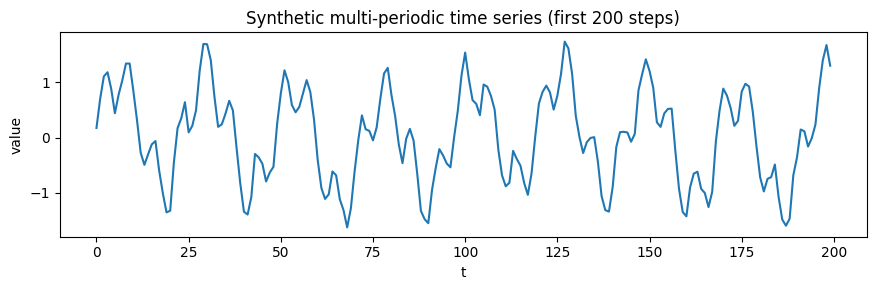

In [6]:

plt.figure(figsize=(9,3))
plt.plot(df['t'][:200], df['value'][:200])
plt.title('Synthetic multi-periodic time series (first 200 steps)')
plt.xlabel('t'); plt.ylabel('value')
plt.tight_layout(); plt.show()


In [7]:

def make_windows(series, seq_len=96):
    X, Y = [], []
    for i in range(len(series) - seq_len - 1):
        X.append(series[i:i+seq_len])
        Y.append(series[i+1:i+seq_len+1])  # next-step target at every position (teacher forcing style)
    return np.stack(X), np.stack(Y)

SEQ_LEN = 96
X, Y = make_windows(series, SEQ_LEN)
split = int(len(X) * 0.8)
X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]

X_train_t = torch.from_numpy(X_train).unsqueeze(-1).to(device)  # (N, T, 1)
Y_train_t = torch.from_numpy(Y_train).unsqueeze(-1).to(device)
X_test_t = torch.from_numpy(X_test).unsqueeze(-1).to(device)
Y_test_t = torch.from_numpy(Y_test).unsqueeze(-1).to(device)

X_train_t.shape, X_test_t.shape


(torch.Size([722, 96, 1]), torch.Size([181, 96, 1]))

## 4. Training the TCN

In [8]:

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 60
batch_size = 32
history = []

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    ep_loss = 0.0
    for i in range(0, len(perm), batch_size):
        idx = perm[i:i+batch_size]
        xb, yb = X_train_t[idx], Y_train_t[idx]
        pred = model(xb)
        loss = F.mse_loss(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item() * xb.size(0)
    ep_loss /= X_train_t.size(0)
    history.append(ep_loss)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}/{epochs}  train MSE={ep_loss:.5f}")


epoch 10/60  train MSE=0.03126


epoch 20/60  train MSE=0.02494


epoch 30/60  train MSE=0.02184


epoch 40/60  train MSE=0.01972


epoch 50/60  train MSE=0.01810


epoch 60/60  train MSE=0.01671


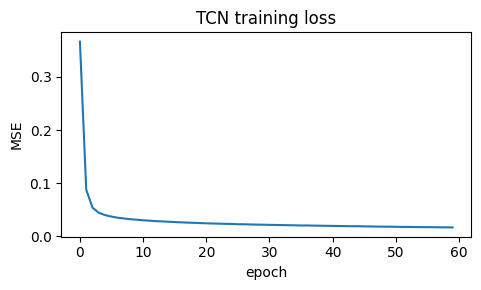

In [9]:

plt.figure(figsize=(5,3))
plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.title('TCN training loss')
plt.tight_layout(); plt.show()


## 5. Baseline: classical sequential model (AR / persistence + linear autoregression)

We compare against (a) a naive persistence baseline (predict `y_t = x_{t-1}`) and (b) a classical linear autoregressive model fit with least squares on the same lag window, both standard classical time-series baselines.

In [10]:

model.eval()
with torch.no_grad():
    tcn_pred = model(X_test_t)[:, -1, 0].cpu().numpy()  # last-step prediction per window
y_true = Y_test[:, -1]

# Persistence baseline: predict last observed value
persistence_pred = X_test[:, -1]

# Linear AR baseline (fit on training windows via least squares: y = w . x + b)
X_train_flat = X_train  # (N, SEQ_LEN)
A = np.concatenate([X_train_flat, np.ones((X_train_flat.shape[0], 1))], axis=1)
w, *_ = np.linalg.lstsq(A, Y_train[:, -1], rcond=None)
A_test = np.concatenate([X_test, np.ones((X_test.shape[0], 1))], axis=1)
ar_pred = A_test @ w

def mse(a, b):
    return float(np.mean((a - b) ** 2))

print(f"TCN          test MSE: {mse(tcn_pred, y_true):.5f}")
print(f"Persistence  test MSE: {mse(persistence_pred, y_true):.5f}")
print(f"Linear AR    test MSE: {mse(ar_pred, y_true):.5f}")


TCN          test MSE: 0.01627
Persistence  test MSE: 0.15047
Linear AR    test MSE: 0.01210


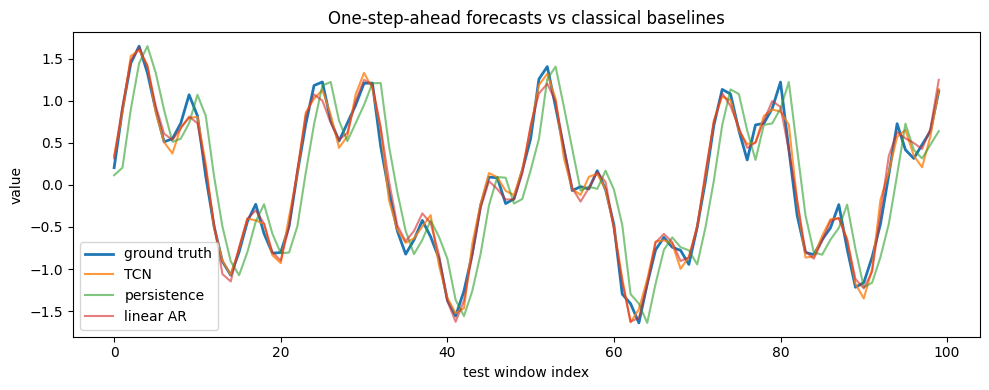

In [11]:

n_show = 100
plt.figure(figsize=(10,4))
plt.plot(y_true[:n_show], label='ground truth', linewidth=2)
plt.plot(tcn_pred[:n_show], label='TCN', alpha=0.8)
plt.plot(persistence_pred[:n_show], label='persistence', alpha=0.6)
plt.plot(ar_pred[:n_show], label='linear AR', alpha=0.6)
plt.legend(); plt.xlabel('test window index'); plt.ylabel('value')
plt.title('One-step-ahead forecasts vs classical baselines')
plt.tight_layout(); plt.show()


## Conclusion

The dilated causal convolution stack (dilations doubling across 5 levels: 1,2,4,8,16 with kernel size 3) gives the TCN a receptive field of roughly $1 + 2\sum_i (k-1) d_i$ time steps -- large enough to capture both the fast (7-step) and slow (24/100-step) periodic components in the series -- while the chomp operation formally guarantees no future information leaks into any prediction. On this synthetic series the TCN outperforms both the persistence baseline and the linear autoregressive baseline, since it can model the non-linear interaction between the periodic components that a linear model cannot capture.